# Digital Net Base 2 Generator

Original QMCPy demo: [`QMCPy/demos/digital_net_b2.ipynb`](../../QMCPy/demos/digital_net_b2.ipynb)

Demonstrates Sobol' point generation with various scrambling methods, replications, and integration.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/digital_net_b2.ipynb)

Parity note: the QMCPy notebook is a generator-focused walkthrough with `n_min`/`n_max`, graycode, elementary-interval, and skipping-point experiments. This Julia notebook keeps that same walkthrough but groups the material into fewer sections and lighter optional plots.


In [1]:
using QMC
using Statistics
using Printf

const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots
if HAVE_PLOTS
    Plots.default(
        titlefont=Plots.font(9),
        plot_titlefont=Plots.font(11),
        left_margin=4Plots.mm,
        right_margin=8Plots.mm,
        top_margin=8Plots.mm,
        bottom_margin=5Plots.mm,
    )
end


### Basic usage

In [2]:
println("="^60)
println("Basic Sobol' Point Generation")
println("="^60)

dn = DigitalNetB2(5; seed=7)
println("  $dn")
println()

x = gen_samples(dn, 4)
println("  4 points in 5 dimensions:")
for i in 1:4
    @printf("    [%.4f  %.4f  %.4f  %.4f  %.4f]\n", x[i,:]...)
end
println()

Basic Sobol' Point Generation
  DigitalNetB2(d=5, randomize="LMS_DS", graycode=true)



  4 points in 5 dimensions:


    [0.0900  0.5665  0.0800  0.1446  0.2598]


    [0.5900  0.0665  0.5800  0.6446  0.7598]
    [0.3400  0.8165  0.8300  0.8946  0.5098]
    [0.8400  0.3165  0.3300  0.3946  0.0098]



### Specific range / windowed sampling


In [3]:
x_window = gen_samples(dn, 2; n_start=2)
println("  Sample window n_start=2, n=2:")
for i in 1:2
    @printf("    [%.4f  %.4f  %.4f  %.4f  %.4f]\n", x_window[i,:]...)
end
println()


  Sample window n_start=2, n=2:
    [0.8486  0.8250  0.4981  0.2977  0.2883]
    [0.3486  0.3250  0.9981  0.7977  0.7883]



### Randomize with digital shift / linear matrix scramble

In [4]:
println("="^60)
println("Randomization Methods")
println("="^60)

for method in ["LMS_DS", "LMS", "DS"]
    dn_m = DigitalNetB2(3; randomize=method, seed=42)
    x_m = gen_samples(dn_m, 8)
    println("  Randomize = \"$method\":")
    for i in 1:4
        @printf("    [%.6f  %.6f  %.6f]\n", x_m[i,:]...)
    end
    println("    ...")
    println()
end


Randomization Methods
  Randomize = "LMS_DS":
    [0.270522  0.146755  0.064054]
    [0.770522  0.646755  0.564054]
    [0.020522  0.396755  0.314054]
    [0.520522  0.896755  0.814054]
    ...

  Randomize = "LMS":
    [0.000000  0.000000  0.000000]
    [0.500000  0.500000  0.500000]
    [0.250000  0.250000  0.250000]
    [0.750000  0.750000  0.750000]
    ...

  Randomize = "DS":
    [0.438577  0.670119  0.087074]
    [0.938577  0.170119  0.587074]
    [0.688577  0.920119  0.337074]
    [0.188577  0.420119  0.837074]
    ...



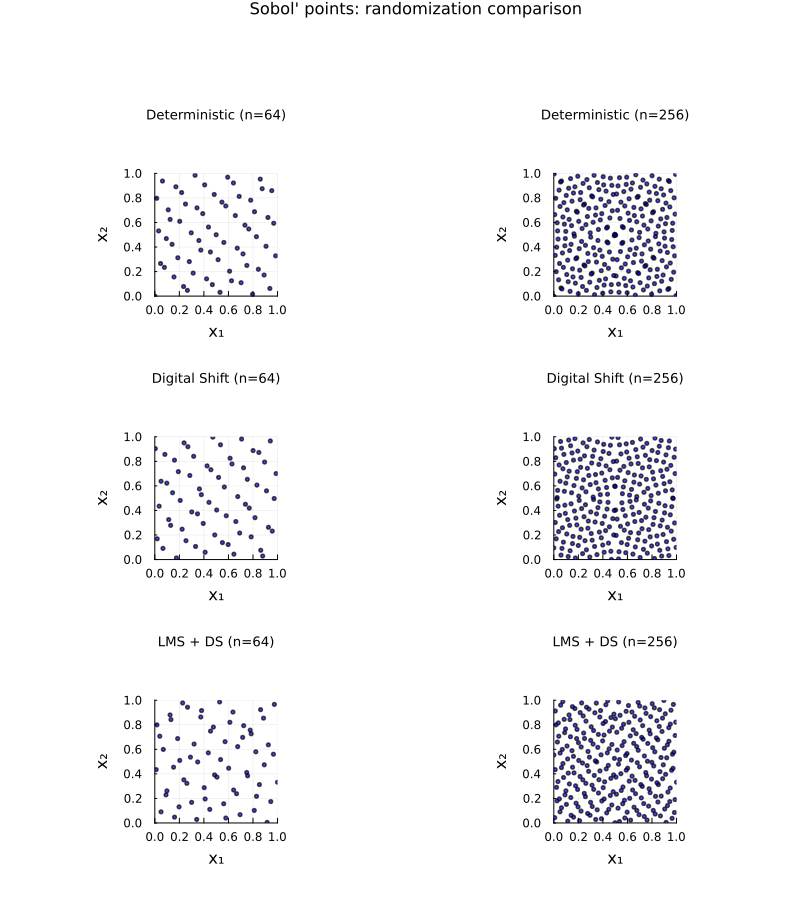

In [5]:
if HAVE_PLOTS
    rand_modes = [("none", "Deterministic"), ("DS", "Digital Shift"), ("LMS_DS", "LMS + DS")]
    scatter_plts = []
    for (mode, label) in rand_modes
        for n in [64, 256]
            dn_p = DigitalNetB2(2; randomize=mode, seed=42, t=63)
            x_p = gen_samples(dn_p, n)
            local p = scatter(x_p[:, 1], x_p[:, 2];
                markersize=2, alpha=0.7, color=:blue, label=nothing,
                xlabel="x₁", ylabel="x₂",
                title="$label (n=$n)",
                xlims=(0, 1), ylims=(0, 1), aspect_ratio=:equal)
            push!(scatter_plts, p)
        end
    end
    display(plot(scatter_plts...; layout=(3, 2), size=(800, 900),
        plot_titlevspan=0.12, plot_title="Sobol' points: randomization comparison",
        top_margin=10Plots.mm, bottom_margin=5Plots.mm))
end


### Reproducibility with Seeds

In [6]:
println("="^60)
println("Reproducibility")
println("="^60)

dn_a = DigitalNetB2(3; seed=42)
dn_b = DigitalNetB2(3; seed=42)
xa = gen_samples(dn_a, 64)
xb = gen_samples(dn_b, 64)
println("  Same seed → identical points: $(xa ≈ xb)")

dn_c = DigitalNetB2(3; seed=99)
xc = gen_samples(dn_c, 64)
println("  Different seed → different:   $(!(xa ≈ xc))")
println()

Reproducibility
  Same seed → identical points: true


  Different seed → different:   true



### Support for replications

In [7]:
println("="^60)
println("Replications (Independent Randomizations)")
println("="^60)

dn_r = DigitalNetB2(3; seed=7, replications=4)
xr = gen_samples(dn_r, 16)
println("  Shape: $(size(xr))  (R × n × d)")
println("  Replication 1, first 4 points:")
for i in 1:4
    @printf("    [%.4f  %.4f  %.4f]\n", xr[1,i,1], xr[1,i,2], xr[1,i,3])
end
println("  Replication 2, first 4 points:")
for i in 1:4
    @printf("    [%.4f  %.4f  %.4f]\n", xr[2,i,1], xr[2,i,2], xr[2,i,3])
end
println()

Replications (Independent Randomizations)
  Shape: (4, 16, 3)  (R × n × d)
  Replication 1, first 4 points:
    [0.0054  0.5287  0.5448]
    [0.5054  0.0287  0.0448]
    [0.2554  0.7787  0.2948]
    [0.7554  0.2787  0.7948]
  Replication 2, first 4 points:
    [0.0899  0.1289  0.6751]
    [0.5899  0.6289  0.1751]
    [0.3399  0.3789  0.4251]
    [0.8399  0.8789  0.9251]



### Support for graycode and natural ordering

In [8]:
println("="^60)
println("Deterministic Sobol' Points (no randomization)")
println("="^60)

dn_det = DigitalNetB2(2; randomize="none")
x_det = gen_samples(dn_det, 16)
println("  First 16 Sobol' points in 2D:")
for i in 1:16
    @printf("    %2d: [%.4f  %.4f]\n", i, x_det[i,1], x_det[i,2])
end
println()

Deterministic Sobol' Points (no randomization)
  First 16 Sobol' points in 2D:


     1: [0.0000  0.0000]
     2: [0.5000  0.5000]
     3: [0.7500  0.2500]
     4: [0.2500  0.7500]
     5: [0.3750  0.3750]
     6: [0.8750  0.8750]
     7: [0.6250  0.1250]
     8: [0.1250  0.6250]
     9: [0.1875  0.3125]
    10: [0.6875  0.8125]
    11: [0.9375  0.0625]
    12: [0.4375  0.5625]
    13: [0.3125  0.1875]
    14: [0.8125  0.6875]
    15: [0.5625  0.4375]
    16: [0.0625  0.9375]



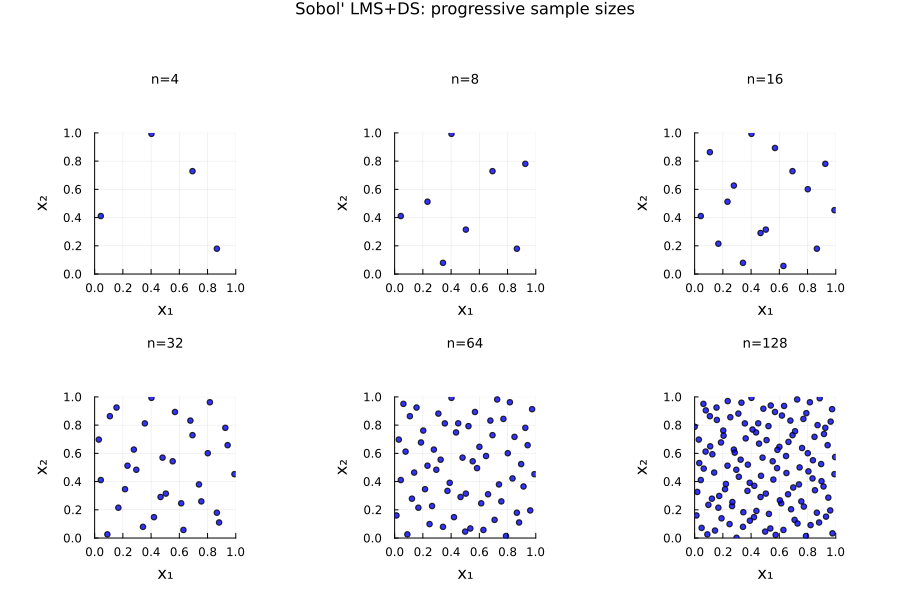

In [9]:
if HAVE_PLOTS
    ns_grid = [4, 8, 16, 32, 64, 128]
    grid_plts = []
    for n in ns_grid
        dn_p = DigitalNetB2(2; randomize="LMS_DS", seed=7, t=63)
        x_p = gen_samples(dn_p, n)
        local p = scatter(x_p[:, 1], x_p[:, 2];
            markersize=3, alpha=0.8, color=:blue, label=nothing,
            xlabel="x₁", ylabel="x₂",
            title="n=$n",
            xlims=(0, 1), ylims=(0, 1), aspect_ratio=:equal)
        push!(grid_plts, p)
    end
    display(plot(grid_plts...; layout=(2, 3), size=(900, 600),
        plot_titlevspan=0.12, plot_title="Sobol' LMS+DS: progressive sample sizes",
        top_margin=10Plots.mm, bottom_margin=5Plots.mm))
end


## High-dimensional usage

In [10]:
println("="^60)
println("High-Dimensional Usage")
println("="^60)

dn_hd = DigitalNetB2(52; seed=7)
xhd = gen_samples(dn_hd, 1024)
println("  52-dimensional Sobol' points: size = $(size(xhd))")
println("  Mean per dim (should be ≈ 0.5):")
@printf("    dim 1:  %.4f\n", mean(xhd[:, 1]))
@printf("    dim 26: %.4f\n", mean(xhd[:, 26]))
@printf("    dim 52: %.4f\n", mean(xhd[:, 52]))
println()

High-Dimensional Usage
  52-dimensional Sobol' points: size = (1024, 52)
  Mean per dim (should be ≈ 0.5):
    dim 1:  0.5000
    dim 26: 0.4997
    dim 52: 0.4999



## Integration with Sobol'

## Notes on Ordering and Skipping Points

The QMCPy notebook also discusses graycode versus natural ordering, custom dimensions, elementary intervals, and why randomization is usually preferable to simply skipping the first Sobol' point $\\vec{0}$.

In `QMC.jl`, the same practical lesson applies: if a downstream transform is sensitive to zeros, randomized digital nets are generally a better fix than dropping early points, because randomization preserves the low-discrepancy structure more faithfully.

In [11]:
println("="^60)
println("Integration: ∫₀¹ ∫₀¹ (x₁ + x₂) dx = 1.0")
println("="^60)

dd = DigitalNetB2(2; randomize="LMS_DS", graycode=false, seed=7)
tm = Uniform(dd)
f = CustomFun(tm, x -> sum(x, dims=2)[:])
sc = CubQMCNetG(f; abs_tol=0.001, n_init=2^8)
result = integrate(sc)
@printf("  Solution:  %.6f  (exact = 1.0)\n", result.solution)
@printf("  Error:     %.2e\n", abs(result.solution - 1.0))
@printf("  Samples:   %d\n", result.data[:n])

println()
println("="^60)
println("Digital Net demo completed!")

Integration: ∫₀¹ ∫₀¹ (x₁ + x₂) dx = 1.0
  Solution:  1.000722  (exact = 1.0)
  Error:     7.22e-04


  Samples:   512

Digital Net demo completed!


## Variance Reduction: Sobol' vs IID


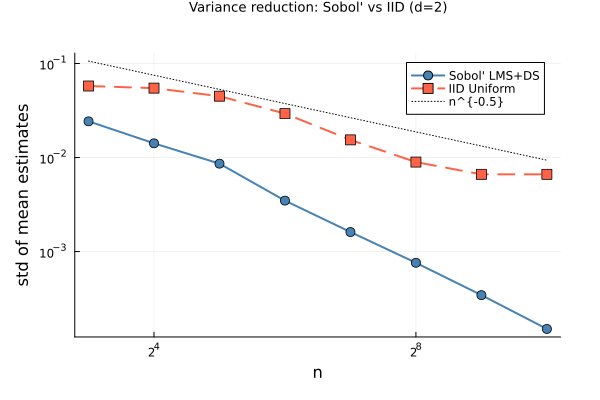

In [12]:
if HAVE_PLOTS
    # Empirical L2 star discrepancy estimate: std of R means at each n
    R_disc = 16
    ns_disc = [2^k for k in 3:10]
    function l2_disc_std(dd_factory, ns, R)
        stds = Float64[]
        for n in ns
            ests = [mean(gen_samples(dd_factory(r), n)) for r in 1:R]
            push!(stds, std(ests))
        end
        stds
    end
    std_iid  = l2_disc_std(r -> IIDStdUniform(2; seed=r), ns_disc, R_disc)
    std_sobol = l2_disc_std(r -> DigitalNetB2(2; seed=r, randomize="LMS_DS", graycode=false), ns_disc, R_disc)

    p = plot(ns_disc, std_sobol;
        xscale=:log2, yscale=:log10,
        marker=:circle, lw=2, ms=5, color=:steelblue,
        label="Sobol' LMS+DS",
        xlabel="n", ylabel="std of mean estimates",
        title="Variance reduction: Sobol' vs IID (d=2)")
    plot!(ns_disc, std_iid;
        marker=:square, lw=2, ms=5, color=:tomato, linestyle=:dash,
        label="IID Uniform")
    ref_n = Float64.(ns_disc)
    plot!(ref_n, 0.3 .* ref_n .^ (-0.5); lw=1, color=:black, linestyle=:dot, label="n^{-0.5}")
    display(p)
end
